# Multi-parameter pilots: what changes as free parameters are added

Every efficiency result in `speedup_analysis.ipynb` (floor/no-floor speed, GPU factors,
the stranded-chain fix) was produced with exactly one free parameter, `a1`. This notebook
compares that single-parameter ladder against the multi-parameter pilots on the systems
they share -- C6, C10, C14 -- and then, in section 6, against reaction count across
everything that has run.

| set | free parameters | systems | outcome |
|---|---|---|---|
| `tightest_nofloor` | `a1` | all 14 | converged everywhere |
| `a1c2_no_floor` | `a1`+`c2` | C6, C10, C14 | never converged; step size never settles (section 2) |
| `a1c3_no_floor` | `a1`+`c3` | C6, C10, C14 | converged on all three |
| `a1c3a2_no_floor` | `a1`+`c3`+`a2` | C6, C10 converged; C14 cancelled | C14 would not finish warmup inside its 24 h compute cap |
| `a1c3d1_no_floor` | `a1`+`c3`+`d1` | C6, C10, C14 all cancelled in warmup | `c3` and `d1` trade off: only their combination is constrained (section 6) |

All pilots are no-floor with `tune=600` and r-hat-only convergence; the single-parameter
ladder used `tune=1000` with r-hat + ESS + rank-ECDF, so draw counts are not an
apples-to-apples comparison of stopping rules (section 3 says so where it matters).

Sections 1-5 are the original pilot checks. Section 6 adds the scaling-with-reaction-count
view across parameter counts, and section 7 summarises every finding these runs produced,
including the Tier-1 identifiability analyses that decide which parameter sets are worth
running next.

In [1]:
import subprocess, json as _json, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REMOTE_PY = "/projects/anth4580/software/anaconda/envs/Bayesian/bin/python"

# Analysis scripts run on an Alpine interactive (acompile) node, never the login node:
# these walk every checkpoint and recompute r-hat/ESS, which is real work and does not
# belong on a shared login node. SLURM_CONF has to be set explicitly -- loading the slurm
# module alone leaves it pointing at whichever cluster the login node belongs to.
SRUN = ("export SLURM_CONF=/curc/slurm/alpine/etc/slurm.conf; "
        "srun --partition=acompile --qos=compile --account=ucb634_asc2 "
        "--nodes=1 --ntasks=1 --cpus-per-task=4 --time=00:40:00 ")

JOBDIR = "/projects/anth4580/Bayesian/job_files"

SETS = ["tightest_nofloor", "a1c2_no_floor", "a1c3_no_floor",
        "a1c3a2_no_floor", "a1c3d1_no_floor"]
PILOT_SYSTEMS = ["C6", "C10", "C14"]   # the only systems the pilot covers
COND_LABEL = {"tightest_nofloor": "a1 only", "a1c2_no_floor": "a1 + c2", "a1c3_no_floor": "a1 + c3",
              "a1c3a2_no_floor": "a1 + c3 + a2", "a1c3d1_no_floor": "a1 + c3 + d1"}

def _pull(script_name, out_name):
    proc = subprocess.run(["ssh", "curc", SRUN + f"{REMOTE_PY} {JOBDIR}/{script_name} " + " ".join(SETS)],
                          stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    if proc.returncode != 0:
        raise RuntimeError(proc.stderr.decode()[-2000:])
    pathlib.Path(out_name).write_bytes(proc.stdout)
    return _json.loads(proc.stdout)

PROGRESS = _pull("export_progress_series.py", "mp_progress.json")
POST = _pull("export_posterior_series.py", "mp_posterior.json")

print("Data availability (systems with any checkpoint data):")
for s in SETS:
    have = sorted(set(PROGRESS.get(s, {})) | set(POST.get(s, {})))
    have_str = have if have else "(none yet)"
    print(f"  {s:<20} {COND_LABEL[s]:<10} -> {have_str}")

Data availability (systems with any checkpoint data):
  tightest_nofloor     a1 only    -> ['C10', 'C12', 'C12+unsat', 'C14', 'C14+unsat', 'C16', 'C16+unsat', 'C18', 'C18+unsat', 'C20', 'C20+unsat', 'C4_NoFB', 'C6', 'C8']
  a1c2_no_floor        a1 + c2    -> ['C10', 'C14', 'C6']
  a1c3_no_floor        a1 + c3    -> ['C10', 'C14', 'C6']
  a1c3a2_no_floor      a1 + c3 + a2 -> ['C10', 'C14', 'C6']
  a1c3d1_no_floor      a1 + c3 + d1 -> ['C10', 'C14', 'C6']


## 1. Cost scaling with parameter count

Median seconds-per-ODE-solve (warmup phase, windowed) and median seconds-per-draw
(sampling phase, once reached), one-parameter baseline vs. each two-parameter pilot,
same systems. A meaningfully higher 2-parameter cost isn't necessarily a problem
(more gradient dimensions costing more is expected) -- what matters is *how much*
more, since that's what determines whether the full multi-parameter model can fit
inside the 2-week/A100 target.

In [2]:
def cost_per_solve_from_progress(rec, phase="warmup", width=5):
    """Median s/solve from a progress-series record's raw step->seconds map,
    using the solves-per-checkpoint block stat -- same method
    speedup_analysis.ipynb uses, self-contained here rather than imported
    (notebooks don\'t import cells from each other)."""
    series = {int(k): v for k, v in (rec.get(phase, {}) or {}).items()}
    solves = {int(k): v for k, v in (rec.get(f"solves_{phase}", {}) or {}).items()}
    if not series or not solves:
        return None
    ks = sorted(series)
    ys = []
    a = ks[0]
    for k in ks[1:]:
        if k - a >= width:
            n = sum(v for kk, v in solves.items() if a < kk <= k)
            dt = series[k] - series[a]
            if n > 0 and dt > 0:
                ys.append(dt / n)
            a = k
    return float(np.median(ys)) if ys else None


def sampling_rate_from_progress(rec, width=5):
    samp = {int(k): v for k, v in (rec.get("sampling", {}) or {}).items()}
    if len(samp) < 2:
        return None
    ks = sorted(samp)
    ys = []
    a = ks[0]
    for k in ks[1:]:
        if k - a >= width:
            dt = samp[k] - samp[a]
            if dt > 0:
                ys.append(dt / (k - a))
            a = k
    return float(np.median(ys)) if ys else None


rows = []
for sysname in PILOT_SYSTEMS:
    for s in SETS:
        rec = PROGRESS.get(s, {}).get(sysname)
        cps = cost_per_solve_from_progress(rec) if rec else None
        srate = sampling_rate_from_progress(rec) if rec else None
        rows.append(dict(system=sysname, condition=COND_LABEL[s],
                         median_s_per_solve=round(cps, 4) if cps else None,
                         median_s_per_draw=round(srate, 3) if srate else None))
df_cost = pd.DataFrame(rows)
display(df_cost)
if df_cost["median_s_per_solve"].isna().all() and df_cost["median_s_per_draw"].isna().all():
    print("No pilot data yet -- this table will populate once a1c2_no_floor/a1c3_no_floor jobs run.")

,system,condition,median_s_per_solve,median_s_per_draw
0,C6,a1 only,0.4318,8.310
1,C6,a1 + c2,0.6768,NaN
2,C6,a1 + c3,0.4475,10.536
3,C6,a1 + c3 + a2,0.5424,47.228
4,C6,a1 + c3 + d1,0.7873,NaN
5,C10,a1 only,0.6484,12.072
6,C10,a1 + c2,2.3810,NaN
7,C10,a1 + c3,0.6935,19.064
8,C10,a1 + c3 + a2,0.7449,60.968
9,C10,a1 + c3 + d1,0.9088,NaN


### How much longer does a1+c3 take, and does that gap grow with system size?

a1+c2 never reached the sampling phase (Section 1 above), so this is a1-only vs.
a1+c3 only. Per-solve cost during warmup barely moves between the two (a single
ODE integration doesn't know how many parameters are being sampled) -- the real
cost of a second free parameter shows up in sampling-phase seconds/draw, since
that's what NUTS actually spends more on: longer leapfrog trajectories per draw
as the joint posterior's geometry gets harder to move through, not a pricier
individual step.

Only 3 systems (C6/C10/C14), so the exponent fit below is a rough, directional
read, not a tight estimate -- the same caveat `speedup_analysis.ipynb`'s own
`MIN_POINTS=3` threshold flags for a line of best fit through exactly three
points.

In [3]:
N_REACTIONS = {"C6": 121, "C10": 199, "C14": 277}

rows = []
for sysname in PILOT_SYSTEMS:
    base = PROGRESS.get("tightest_nofloor", {}).get(sysname)
    pilot = PROGRESS.get("a1c3_no_floor", {}).get(sysname)
    r_base = sampling_rate_from_progress(base) if base else None
    r_pilot = sampling_rate_from_progress(pilot) if pilot else None
    rows.append(dict(system=sysname, reactions=N_REACTIONS[sysname],
                     a1_only_s_per_draw=round(r_base, 3) if r_base else None,
                     a1_c3_s_per_draw=round(r_pilot, 3) if r_pilot else None,
                     ratio=round(r_pilot / r_base, 3) if r_base and r_pilot else None))
df_timing = pd.DataFrame(rows)
display(df_timing)

if df_timing["ratio"].notna().sum() >= 3:
    rx = df_timing["reactions"].to_numpy(dtype=float)
    y_base = df_timing["a1_only_s_per_draw"].to_numpy(dtype=float)
    y_pilot = df_timing["a1_c3_s_per_draw"].to_numpy(dtype=float)
    ratio = df_timing["ratio"].to_numpy(dtype=float)

    def loglog_slope(x, y):
        """Power-law exponent (slope in log-log space) + R^2, matching the
        method speedup_analysis.ipynb's fit_rate() uses for cost-vs-size trends."""
        s, i = np.polyfit(np.log(x), np.log(y), 1)
        r2 = 1 - np.sum((np.log(y) - (s * np.log(x) + i)) ** 2) / np.sum((np.log(y) - np.log(y).mean()) ** 2)
        return s, r2

    s_base, r2_base = loglog_slope(rx, y_base)
    s_pilot, r2_pilot = loglog_slope(rx, y_pilot)
    s_ratio, r2_ratio = loglog_slope(rx, ratio)

    print(f"cost/draw ~ reactions^{s_base:.2f}  (a1 only,  R2={r2_base:.3f})")
    print(f"cost/draw ~ reactions^{s_pilot:.2f}  (a1 + c3,  R2={r2_pilot:.3f})")
    print(f"ratio (a1+c3 / a1-only) grows as reactions^{s_ratio:.2f} across "
          f"{int(rx.min())}-{int(rx.max())} reactions "
          f"({ratio.min():.2f}x -> {ratio.max():.2f}x)")
    if s_pilot > s_base:
        print("\na1+c3 costs more per draw at every system size AND that cost grows "
              "faster with reaction count than a1-only's does -- the second free "
              "parameter isn't just a fixed overhead, it gets relatively more "
              "expensive as the system scales up. Only 3 points, so treat the "
              "exponents as directional, not precise.")
else:
    print("Need sampling-phase data for all three systems in both conditions.")

,system,reactions,a1_only_s_per_draw,a1_c3_s_per_draw,ratio
0,C6,121,8.310,10.536,1.268
1,C10,199,12.072,19.064,1.579
2,C14,277,15.208,28.768,1.892


cost/draw ~ reactions^0.73  (a1 only,  R2=1.000)
cost/draw ~ reactions^1.21  (a1 + c3,  R2=1.000)
ratio (a1+c3 / a1-only) grows as reactions^0.48 across 121-277 reactions (1.27x -> 1.89x)

a1+c3 costs more per draw at every system size AND that cost grows faster with reaction count than a1-only's does -- the second free parameter isn't just a fixed overhead, it gets relatively more expensive as the system scales up. Only 3 points, so treat the exponents as directional, not precise.


## 2. Mass-matrix adequacy

Step-size and acceptance-rate distributions during warmup, one-parameter baseline
vs. two-parameter pilot. A diagonal mass matrix (`is_mass_matrix_diagonal=True`,
unchanged for this pilot) is only trivially adequate at one dimension -- a
correlated pair of parameters could show up here first as an unusually small
adapted step size or a depressed acceptance rate, before it shows up as an outright
convergence failure.

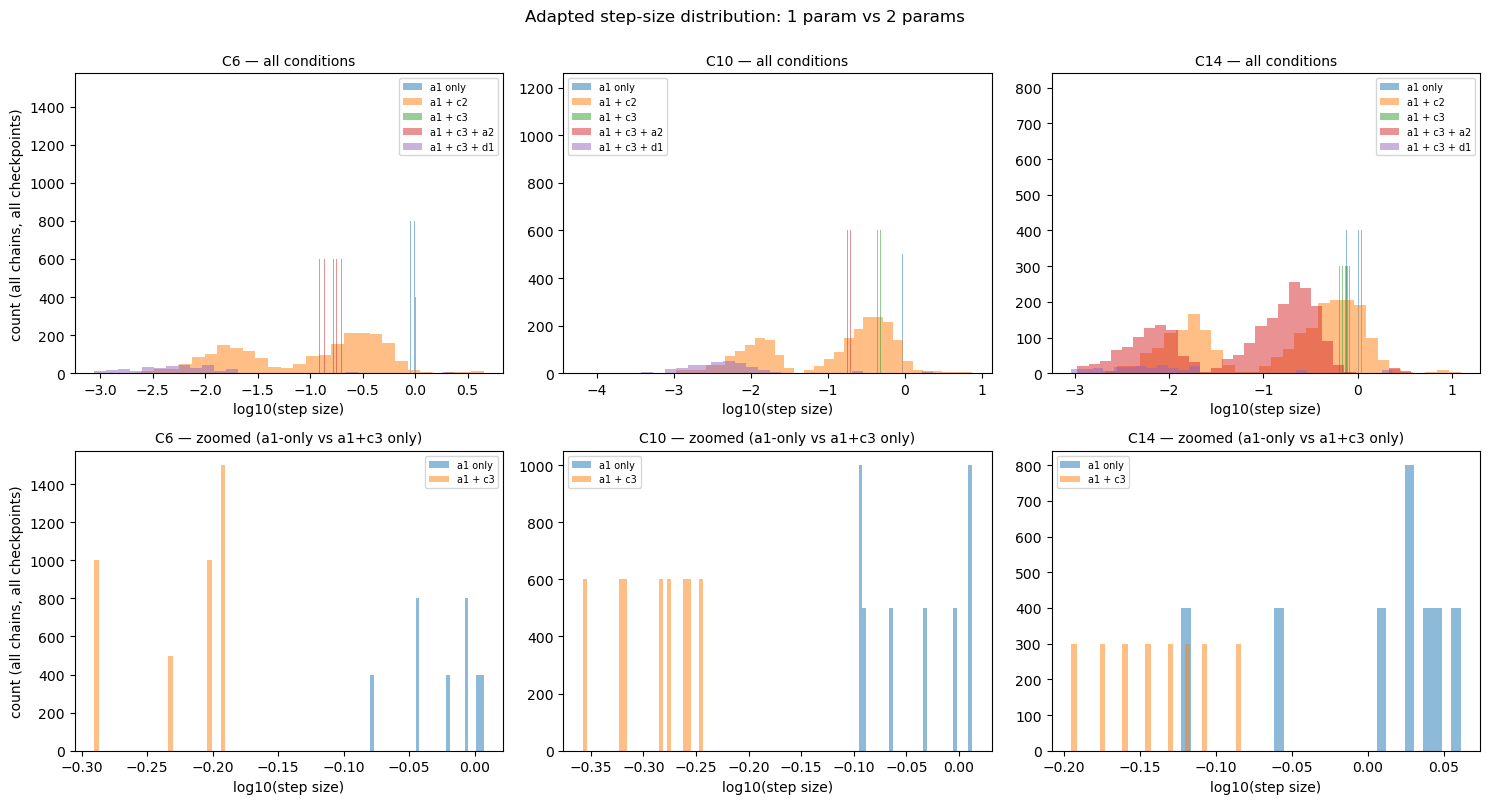

,system,condition,source,n_chains,mean_acceptance
0,C6,a1 only,sampling,8,0.9342
1,C6,a1 + c2,warmup,8,0.7801
2,C6,a1 + c3,sampling,8,0.9335
3,C6,a1 + c3 + a2,sampling,8,0.9365
4,C6,a1 + c3 + d1,warmup,8,0.7291
5,C10,a1 only,sampling,8,0.9342
6,C10,a1 + c2,warmup,8,0.7798
7,C10,a1 + c3,sampling,8,0.9416
8,C10,a1 + c3 + a2,sampling,8,0.9393
9,C10,a1 + c3 + d1,warmup,8,0.7239


In [4]:
fig, axes = plt.subplots(2, len(PILOT_SYSTEMS), figsize=(5 * len(PILOT_SYSTEMS), 8.0), squeeze=False)
any_data = False
for ax, sysname in zip(axes[0], PILOT_SYSTEMS):
    for s in SETS:
        rec = POST.get(s, {}).get(sysname)
        if not rec or "step_size" not in rec:
            continue
        any_data = True
        ss = np.array(rec["step_size"]).ravel()
        ax.hist(np.log10(ss[ss > 0]), bins=30, alpha=0.5, label=COND_LABEL[s])
    ax.set_title(f"{sysname} — all conditions", fontsize=10)
    ax.set_xlabel("log10(step size)")
    ax.legend(fontsize=7)
axes[0, 0].set_ylabel("count (all chains, all checkpoints)")

# a1-only and a1+c3 each settle on one step size confined to a log10 range
# ~30-40x narrower than a1+c2's bimodal spread (checked directly: e.g. C6 is
# 0.086/0.100 wide for a1-only/a1+c3 vs 3.62 for a1+c2). Sharing the axis above
# with a1+c2 compresses both into a sliver a couple of percent of the visible
# x-range wide -- easy to mistake for missing data, which it isn't. Re-plotted
# here on their own axis, excluding a1+c2, so the comparison this section is
# actually about (does a1-only's adaptation look like a1+c3's) is visible.
NARROW_SETS = ["tightest_nofloor", "a1c3_no_floor"]
for ax, sysname in zip(axes[1], PILOT_SYSTEMS):
    for s in NARROW_SETS:
        rec = POST.get(s, {}).get(sysname)
        if not rec or "step_size" not in rec:
            continue
        ss = np.array(rec["step_size"]).ravel()
        ax.hist(np.log10(ss[ss > 0]), bins=30, alpha=0.5, label=COND_LABEL[s])
    ax.set_title(f"{sysname} — zoomed (a1-only vs a1+c3 only)", fontsize=10)
    ax.set_xlabel("log10(step size)")
    ax.legend(fontsize=7)
axes[1, 0].set_ylabel("count (all chains, all checkpoints)")

fig.suptitle("Adapted step-size distribution: 1 param vs 2 params", fontsize=12, y=1.0)
plt.tight_layout(); plt.show()
if not any_data:
    print("No pilot step-size data yet.")

rows = []
for sysname in PILOT_SYSTEMS:
    for s in SETS:
        rec = POST.get(s, {}).get(sysname)
        if not rec:
            continue
        acc = np.array(rec.get("accept", []))
        rows.append(dict(system=sysname, condition=COND_LABEL[s],
                         source=rec["source"], n_chains=rec["n_chains"],
                         mean_acceptance=round(float(acc.mean()), 4) if acc.size else None))
df_accept = pd.DataFrame(rows)
display(df_accept)

**Why a1+c2's step size is bimodal while a1-only/a1+c3 aren't.** Checked
directly against the raw per-chain `step_size` arrays: a1-only and a1+c3 each
converge to one dominant, narrow step size within the first ~10-15% of warmup
and hold it for the rest of the run. a1+c2 never settles the same way -- its
step size keeps oscillating between a "corrective" small value (~0.01-0.03,
hit when the sampler crosses the a1-c2 correlation ridge and dual-averaging
shrinks hard) and a larger relaxed value (~0.2-0.3, once it's back off the
ridge), for the entire 265-draw warmup. Pooled over all chains and
checkpoints, that shows up as two real peaks -- the same a1-c2 correlation
problem Section 2 raised, visible here as an adaptation history that never
stabilizes.

a1-only's and a1+c3's own step sizes are confined to a log10 range only
~0.09-0.18 wide, versus a1+c2's ~3.6-3.8 -- about 30-40x wider. Sharing one
linear axis sized to fit a1+c2 compresses the narrower two into a sliver a
couple of percent of the visible width, easy to miss. The zoomed row below
excludes a1+c2 so both show up clearly, as a handful of narrow, discrete
spikes -- discrete because the pilot's short warmup budget only lets
dual-averaging visit a few distinct step sizes before tune ends, not because
the underlying adaptation is actually discontinuous.

## 3. Convergence draw-count, on one rule for every run

Two columns, and the difference between them is the point.

`stopped_at_draws` is what each run actually did, and the runs did not all stop under
the same rule: the 1-parameter baseline stopped on r-hat plus a flat bulk ESS >= 400,
while the pilots stopped on r-hat alone (`ess_threshold=null`, rank-ECDF removed, by
explicit request to keep the pilot fast). Comparing those numbers across conditions
compares the stopping rules as much as the parameter sets.

`criteria_draw_scaled` fixes that. It is recomputed from each run's stored posterior
under one rule applied identically everywhere -- rank-normalised r-hat < 1.01 and bulk
ESS >= 100 x chains, the per-split-chain requirement of Vehtari et al. 2021 (>= 50 in
each half of each chain) -- so this column *is* a controlled comparison of how many
draws each parameter set needs. The flat 400 the baseline actually used was half the
bar its 8 chains warranted, which is why the two columns differ even for `a1 only`.

Both columns count sampling draws only. A run whose `criteria_draw_scaled` is blank
either has no finalized posterior yet or never met the rule within the draws it took.


In [5]:
# Recomputed by job_files/regen_convergence_figs.py from each run's stored posterior,
# so every condition is scored on the same rule regardless of what stopped it.
_regen = {r["run"]: r for r in _json.loads(pathlib.Path("../regen_convergence_figs.json").read_text())
          if "criteria_at_new" in r}

def _run_dir(setname, sysname):
    """Result-folder name for a set/system pair; the baseline set predates the naming."""
    tail = "a1_0.1-10_no_floor" if setname == "tightest_nofloor" else setname
    return f"Chain {sysname} - {tail}"

rows = []
for sysname in PILOT_SYSTEMS:
    for s in SETS:
        prog = PROGRESS.get(s, {}).get(sysname)
        rec = _regen.get(_run_dir(s, sysname))
        rows.append(dict(system=sysname, condition=COND_LABEL[s],
                         stopped_at_draws=prog.get("converged_at") if prog else None,
                         chains=rec["chains"] if rec else None,
                         ess_bar_scaled=rec["ess_new"] if rec else None,
                         criteria_draw_scaled=rec["criteria_at_new"] if rec else None))
df_converge = pd.DataFrame(rows)
display(df_converge)
if df_converge["stopped_at_draws"].isna().all():
    print("No pilot convergence data yet.")

_scored = df_converge.dropna(subset=["criteria_draw_scaled"])
if len(_scored):
    print("\nUnder the single scaled rule, median sampling draws to converge:")
    for cond, g in _scored.groupby("condition", sort=False):
        print(f"  {cond:<14} {g['criteria_draw_scaled'].median():>6.0f}  "
              f"(n={len(g)}: {', '.join(g['system'])})")


,system,condition,stopped_at_draws,chains,ess_bar_scaled,criteria_draw_scaled
0,C6,a1 only,400.0,8.0,800.0,240.0
1,C6,a1 + c2,NaN,NaN,NaN,NaN
2,C6,a1 + c3,500.0,8.0,800.0,230.0
3,C6,a1 + c3 + a2,600.0,8.0,800.0,570.0
4,C6,a1 + c3 + d1,NaN,NaN,NaN,NaN
5,C10,a1 only,500.0,8.0,800.0,310.0
6,C10,a1 + c2,NaN,NaN,NaN,NaN
7,C10,a1 + c3,600.0,8.0,800.0,320.0
8,C10,a1 + c3 + a2,600.0,8.0,800.0,460.0
9,C10,a1 + c3 + d1,NaN,NaN,NaN,NaN



Under the single scaled rule, median sampling draws to converge:
  a1 only           260  (n=3: C6, C10, C14)
  a1 + c3           230  (n=3: C6, C10, C14)
  a1 + c3 + a2      515  (n=2: C6, C10)


## 4. Stranded-chain behavior with a second free parameter

Same log-posterior-gap check used throughout `speedup_analysis.ipynb`, generalized
to however many free parameters a run has. **Interpretation differs from the
single-parameter case**: there, the user confirmed a1 alone cannot have a second
valid solution, so a detected split was treated as a numerical artifact (confirmed
via a floor-vs-no-floor predictive-check comparison). With a second parameter free,
a real competing joint solution is physically plausible -- a split found here needs
a predictive-check comparison (same method used on C10-narrowest) before assuming
either "artifact" or "real", not an automatic default either way.

In [6]:
GAP_NATS = 20.0  # same threshold resumable_sampler.py uses

def stranded_check(rec):
    if not rec:
        return None
    lp = np.array(rec["lp"])
    window = min(200, max(20, lp.shape[1] // 4))
    means = lp[:, -window:].mean(axis=1)
    gaps = means.max() - means
    stranded = [c for c in range(len(means)) if gaps[c] > GAP_NATS]
    return dict(n_chains=len(means), stranded=stranded,
               worst_gap=round(float(gaps.max()), 1),
               params_at_stranded={name: [round(float(v), 4) for v in np.array(arr)[stranded, -1]]
                                   for name, arr in rec["params"].items()} if stranded else {})

rows = []
for sysname in PILOT_SYSTEMS:
    for s in SETS:
        rec = POST.get(s, {}).get(sysname)
        chk = stranded_check(rec)
        if chk is None:
            continue
        rows.append(dict(system=sysname, condition=COND_LABEL[s], n_chains=chk["n_chains"],
                         n_stranded=len(chk["stranded"]), worst_gap_nats=chk["worst_gap"],
                         stranded_param_values=chk["params_at_stranded"] or None))
df_stranded = pd.DataFrame(rows)
display(df_stranded)
if df_stranded.empty:
    print("No pilot posterior data yet.")
elif (df_stranded["n_stranded"] > 0).any():
    print("\nAt least one pilot run shows a stranded-chain split -- see section 4\'s note above "
          "before treating it as an artifact.")

,system,condition,n_chains,n_stranded,worst_gap_nats,stranded_param_values
0,C6,a1 only,8,0,0.4,None
1,C6,a1 + c2,8,0,0.6,None
2,C6,a1 + c3,8,0,0.3,None
3,C6,a1 + c3 + a2,8,0,0.7,None
4,C6,a1 + c3 + d1,8,0,3.9,None
5,C10,a1 only,8,0,0.3,None
6,C10,a1 + c2,8,0,1.1,None
7,C10,a1 + c3,8,0,0.3,None
8,C10,a1 + c3 + a2,8,0,0.4,None
9,C10,a1 + c3 + d1,8,3,84.4,"{'a1': [1.0411, 1.3718, 1.1192], 'c3': [1.0078..."



At least one pilot run shows a stranded-chain split -- see section 4's note above before treating it as an artifact.


## 5. a1+c3 vs. a1-only: the pairing that actually converged

a1+c2 never got past warmup on any of the three pilot systems (Section 1-4's NaNs),
so it has nothing to compare yet. a1+c3 converged on all three (C6/C10/C14) under
the same r-hat-only rule, which is the first real chance to check whether adding a
second free parameter changes what the data says about `a1` -- and to look at `c3`
on its own and at the two parameters jointly, the same mass-matrix-adequacy
question Section 2 raised, now checkable directly against real correlated-pair
draws instead of only the step-size symptom.

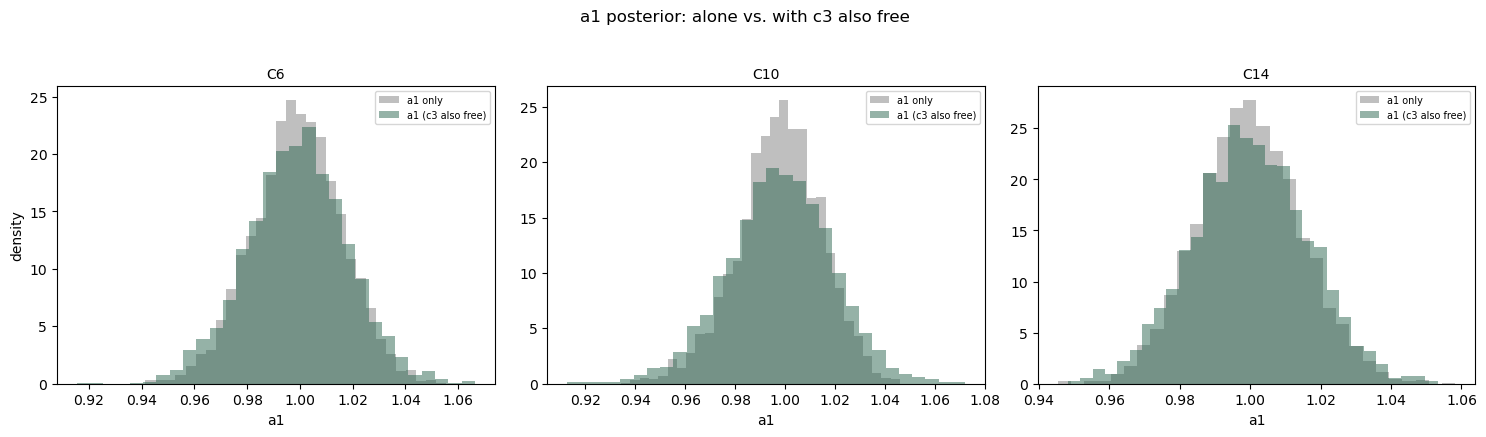

,system,a1_only_mean,a1_only_sd,a1_with_c3_mean,a1_with_c3_sd,sd_ratio_with_c3_over_alone
0,C6,0.9991,0.0169,0.9990,0.0190,1.123
1,C10,0.9977,0.0168,0.9978,0.0212,1.259
2,C14,0.9998,0.0149,1.0001,0.0165,1.107



a1's posterior is noticeably wider with c3 also free on at least one system -- some of a1's identifying information is being shared with c3 rather than fully independent.


In [7]:
fig, axes = plt.subplots(1, len(PILOT_SYSTEMS), figsize=(5 * len(PILOT_SYSTEMS), 4.2), squeeze=False)
axes = axes[0]
for ax, sysname in zip(axes, PILOT_SYSTEMS):
    base = POST.get("tightest_nofloor", {}).get(sysname)
    pilot = POST.get("a1c3_no_floor", {}).get(sysname)
    if base:
        a1_base = np.array(base["params"]["a1"]).ravel()
        ax.hist(a1_base, bins=30, alpha=0.5, density=True, label="a1 only", color="0.5")
    if pilot:
        a1_pilot = np.array(pilot["params"]["a1"]).ravel()
        ax.hist(a1_pilot, bins=30, alpha=0.5, density=True, label="a1 (c3 also free)", color="#2c6650")
    ax.set_title(sysname, fontsize=10)
    ax.set_xlabel("a1")
    ax.legend(fontsize=7)
axes[0].set_ylabel("density")
fig.suptitle("a1 posterior: alone vs. with c3 also free", fontsize=12, y=1.03)
plt.tight_layout(); plt.show()

rows = []
for sysname in PILOT_SYSTEMS:
    base = POST.get("tightest_nofloor", {}).get(sysname)
    pilot = POST.get("a1c3_no_floor", {}).get(sysname)
    if not (base and pilot):
        continue
    a1_base = np.array(base["params"]["a1"]).ravel()
    a1_pilot = np.array(pilot["params"]["a1"]).ravel()
    rows.append(dict(system=sysname,
                     a1_only_mean=round(float(a1_base.mean()), 4),
                     a1_only_sd=round(float(a1_base.std()), 4),
                     a1_with_c3_mean=round(float(a1_pilot.mean()), 4),
                     a1_with_c3_sd=round(float(a1_pilot.std()), 4),
                     sd_ratio_with_c3_over_alone=round(float(a1_pilot.std() / a1_base.std()), 3)))
df_a1_compare = pd.DataFrame(rows)
display(df_a1_compare)
if df_a1_compare.empty:
    print("Need both a1-only and a1+c3 posteriors for the same system to compare.")
elif (df_a1_compare["sd_ratio_with_c3_over_alone"] > 1.2).any():
    print("\na1's posterior is noticeably wider with c3 also free on at least one "
          "system -- some of a1's identifying information is being shared with c3 "
          "rather than fully independent.")

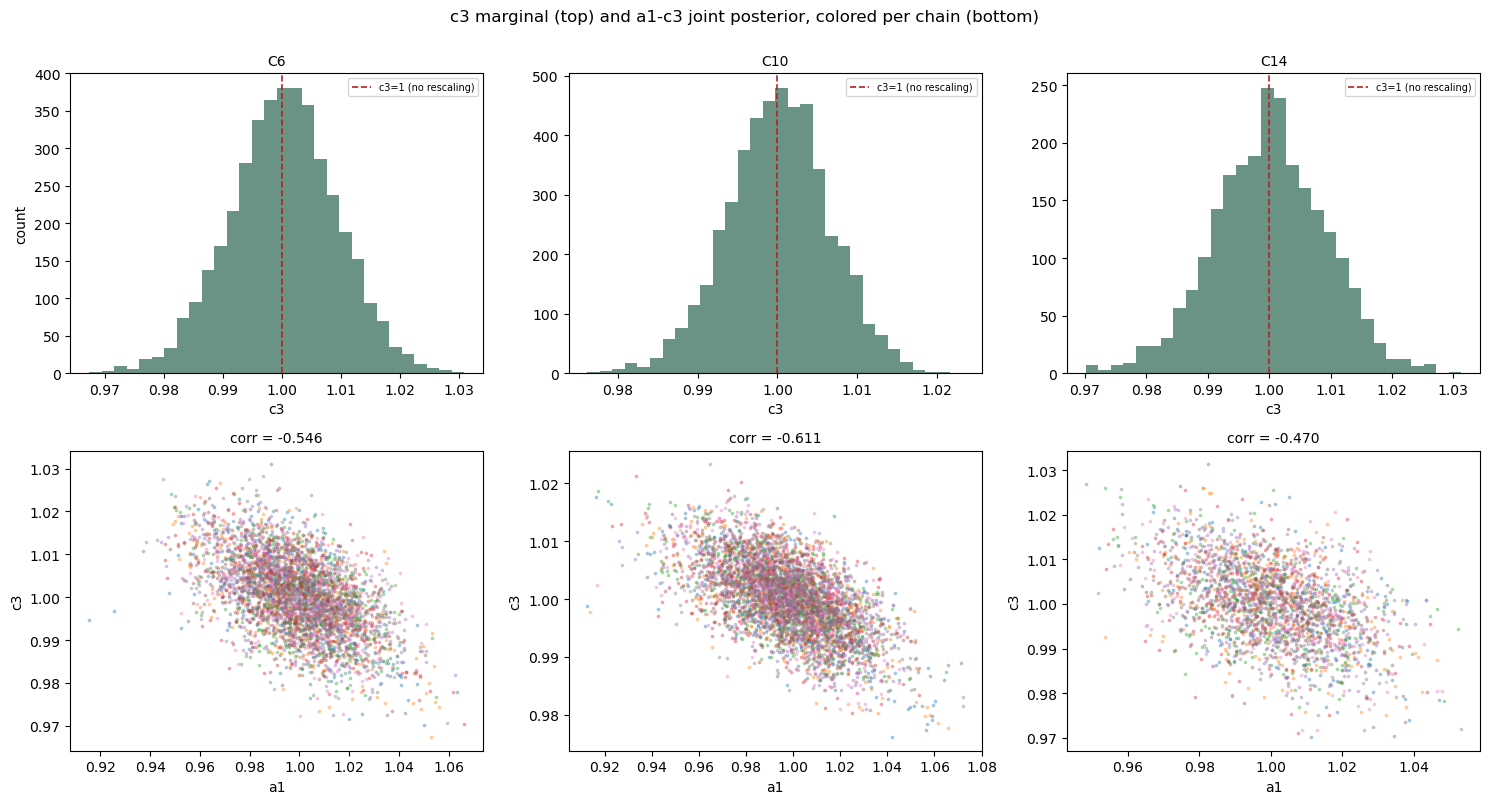

,system,c3_mean,c3_sd,a1_c3_posterior_corr
0,C6,1.0003,0.0090,-0.546
1,C10,1.0001,0.0064,-0.611
2,C14,1.0001,0.0091,-0.470



At least one system shows meaningful a1-c3 posterior correlation -- worth checking whether the diagonal mass matrix is coping (Section 2) even though this pairing converged, same question a1+c2 failed.


In [8]:
fig, axes = plt.subplots(2, len(PILOT_SYSTEMS), figsize=(5 * len(PILOT_SYSTEMS), 8.0), squeeze=False)
rows = []
for col, sysname in enumerate(PILOT_SYSTEMS):
    pilot = POST.get("a1c3_no_floor", {}).get(sysname)
    ax_c3, ax_joint = axes[0, col], axes[1, col]
    if not pilot or "c3" not in pilot.get("params", {}):
        ax_c3.set_title(f"{sysname} (no data)", fontsize=10)
        ax_joint.set_title(f"{sysname} (no data)", fontsize=10)
        continue
    a1 = np.array(pilot["params"]["a1"])
    c3 = np.array(pilot["params"]["c3"])

    ax_c3.hist(c3.ravel(), bins=30, color="#2c6650", alpha=0.7)
    ax_c3.axvline(1.0, color="firebrick", ls="--", lw=1.2, label="c3=1 (no rescaling)")
    ax_c3.set_title(sysname, fontsize=10)
    ax_c3.set_xlabel("c3")
    ax_c3.legend(fontsize=7)

    corr = float(np.corrcoef(a1.ravel(), c3.ravel())[0, 1])
    for c in range(a1.shape[0]):
        ax_joint.scatter(a1[c], c3[c], s=3, alpha=0.3)
    ax_joint.set_xlabel("a1"); ax_joint.set_ylabel("c3")
    ax_joint.set_title(f"corr = {corr:+.3f}", fontsize=10)

    rows.append(dict(system=sysname, c3_mean=round(float(c3.mean()), 4),
                     c3_sd=round(float(c3.std()), 4),
                     a1_c3_posterior_corr=round(corr, 3)))
axes[0, 0].set_ylabel("count")
axes[1, 0].set_ylabel("c3")
fig.suptitle("c3 marginal (top) and a1-c3 joint posterior, colored per chain (bottom)",
            fontsize=12, y=1.0)
plt.tight_layout(); plt.show()

df_c3 = pd.DataFrame(rows)
display(df_c3)
if df_c3.empty:
    print("No a1+c3 posterior data yet.")
elif (df_c3["a1_c3_posterior_corr"].abs() > 0.3).any():
    print("\nAt least one system shows meaningful a1-c3 posterior correlation -- "
          "worth checking whether the diagonal mass matrix is coping (Section 2) "
          "even though this pairing converged, same question a1+c2 failed.")
else:
    print("\na1-c3 posterior correlation is weak everywhere tested -- consistent "
          "with a1+c3 converging cleanly under a diagonal mass matrix where "
          "a1+c2 (sigma/mu* interaction ratio 1.77 vs c3's 1.55) did not.")

## 6. Scaling with reaction count as parameters are added

Sections 1 and 5 compare pilots on three systems. This section puts every run on one
axis -- reaction count -- so the cost of a second and third free parameter can be read
against system size rather than per system.

Timings are converted to **A100-equivalent seconds** first: runs land on whatever card
Blanca or Alpine has free, and the measured speed factors (H100 NVL 1.37, A100 1.00,
V100 0.67-0.75) differ by up to 2x, which is larger than several of the effects here.
`resumable_sampler` now banks compute in these units for the same reason.

In [9]:
# Reaction counts per system, and the measured GPU speed factors
# (resumable_sampler.GPU_SPEED_VS_A100 -- see Notes/full_audit_request_v3_annotated.md
# for how they were cross-validated).
N_REACTIONS_ALL = {"C4_NoFB": 56, "C6": 121, "C8": 160, "C10": 199, "C12": 238,
                   "C12+unsat": 274, "C14": 277, "C14+unsat": 352, "C16": 316,
                   "C16+unsat": 430, "C18": 355, "C18+unsat": 508, "C20": 394, "C20+unsat": 586}
N_PARAMS = {"tightest_nofloor": 1, "a1c2_no_floor": 2, "a1c3_no_floor": 2,
            "a1c3a2_no_floor": 3, "a1c3d1_no_floor": 3}
GPU_SPEED_VS_A100 = [("H100 NVL", 1.37), ("MIG 3g.40gb", 0.90), ("A100", 1.00),
                     ("V100-SXM2", 0.67), ("V100", 0.75)]


def device_factor(rec, phase):
    """Speed factor of the card this phase mostly ran on; 1.0 (A100) if unknown.
    Multiplying a measured time by it gives the time the same work would take on an A100."""
    devs = [d for d in (rec.get(f"device_{phase}", {}) or {}).values() if d]
    if not devs:
        return 1.0
    dev = max(set(devs), key=devs.count)
    for key, f in GPU_SPEED_VS_A100:
        if key in dev:
            return f
    return 1.0


def warmup_rate(rec, width=5, skip_first=2):
    """Median A100-equivalent seconds per warmup step. The first checkpoints include
    JIT compilation (~25 min on C6), so they are dropped rather than averaged in."""
    d = {int(k): v for k, v in (rec.get("warmup", {}) or {}).items()}
    ks = sorted(d)[skip_first:]
    ys = [(d[b] - d[a]) / (b - a) for a, b in zip(ks, ks[1:]) if b - a >= width and d[b] > d[a]]
    return float(np.median(ys)) * device_factor(rec, "warmup") if ys else None


def total_compute_hours(rec):
    w = max((v for v in (rec.get("warmup", {}) or {}).values()), default=0) * device_factor(rec, "warmup")
    s = max((v for v in (rec.get("sampling", {}) or {}).values()), default=0) * device_factor(rec, "sampling")
    return (w + s) / 3600 if (w or s) else None


def median_grad_evals(setname, sysname):
    """Leapfrog steps per draw: the count of gradient evaluations, each of which solves
    the ODE once per condition. This is what a harder posterior geometry actually costs."""
    rec = POST.get(setname, {}).get(sysname)
    if not rec or not rec.get("n_steps"):
        return None, None
    n = np.asarray(rec["n_steps"], dtype=float)
    return float(np.median(n)), rec.get("source")


rows = []
for setname in SETS:
    for sysname, rec in sorted((PROGRESS.get(setname) or {}).items(),
                               key=lambda kv: N_REACTIONS_ALL.get(kv[0], 0)):
        s_draw = sampling_rate_from_progress(rec)
        grads, src = median_grad_evals(setname, sysname)
        rows.append(dict(
            set=setname, condition=COND_LABEL[setname], n_params=N_PARAMS[setname],
            system=sysname, reactions=N_REACTIONS_ALL.get(sysname),
            warmup_s_per_step=round(warmup_rate(rec), 2) if warmup_rate(rec) else None,
            s_per_draw=round(s_draw * device_factor(rec, "sampling"), 2) if s_draw else None,
            s_per_solve=round(cost_per_solve_from_progress(rec) * device_factor(rec, "warmup"), 4)
                        if cost_per_solve_from_progress(rec) else None,
            grad_evals_per_draw=grads, phase=src,
            # Where this run stopped, under whichever rule it ran with; section 3 has the
                # column that scores every run on the settled scaled-ESS rule instead.
                stopped_at_draws=rec.get("converged_at"),
            total_compute_h=round(total_compute_hours(rec), 2) if total_compute_hours(rec) else None))
df_scale = pd.DataFrame(rows)
display(df_scale)

,set,condition,n_params,system,reactions,warmup_s_per_step,s_per_draw,s_per_solve,grad_evals_per_draw,phase,stopped_at_draws,total_compute_h
0,tightest_nofloor,a1 only,1,C4_NoFB,56,7.78,5.62,0.3130,3.0,sampling,700.0,3.57
1,tightest_nofloor,a1 only,1,C6,121,8.34,8.31,0.4318,3.0,sampling,400.0,7.67
2,tightest_nofloor,a1 only,1,C8,160,11.44,7.30,0.5910,3.0,sampling,3000.0,12.17
3,tightest_nofloor,a1 only,1,C10,199,12.62,12.07,0.6484,3.0,sampling,500.0,14.50
4,tightest_nofloor,a1 only,1,C12,238,15.90,10.02,0.8185,3.0,sampling,400.0,8.96
5,tightest_nofloor,a1 only,1,C12+unsat,274,17.33,14.79,0.8922,3.0,sampling,500.0,10.35
6,tightest_nofloor,a1 only,1,C14,277,18.14,15.21,0.9388,3.0,sampling,400.0,12.66
7,tightest_nofloor,a1 only,1,C16,316,27.39,23.09,1.4247,3.0,sampling,400.0,13.63
8,tightest_nofloor,a1 only,1,C14+unsat,352,23.69,20.06,1.2481,3.0,sampling,400.0,12.74
9,tightest_nofloor,a1 only,1,C18,355,42.73,36.33,2.2199,3.0,sampling,400.0,19.43


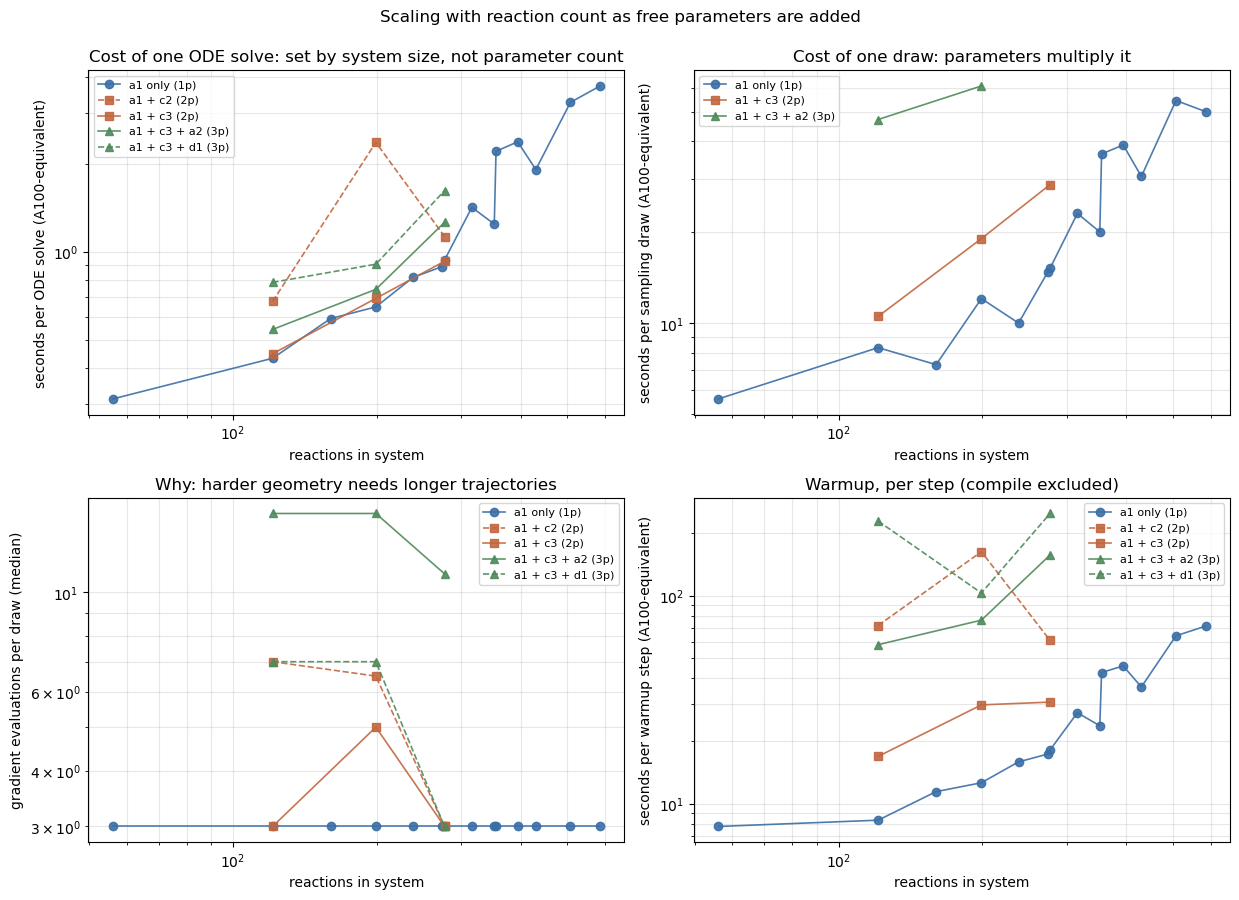

cost/draw ~ reactions^k   (A100-equivalent, log-log fit)
  a1 only        k = 1.08   (14 systems, 56-586 reactions)
  a1 + c2        only 0 system(s) with sampling data -- no fit
  a1 + c3        k = 1.21   (3 systems, 121-277 reactions)
  a1 + c3 + a2   only 2 system(s) with sampling data -- no fit
  a1 + c3 + d1   only 0 system(s) with sampling data -- no fit

cost per draw relative to a1 alone, same system:
  a1 + c2        no sampling-phase data
  a1 + c3        C6 1.3x, C10 1.6x, C14 1.9x
  a1 + c3 + a2   C6 5.7x, C10 5.1x
  a1 + c3 + d1   no sampling-phase data


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 9.0))
STYLE = {1: ("o", "#3b6ea5"), 2: ("s", "#c1663f"), 3: ("^", "#4f8a5b")}
panels = [("s_per_solve", "seconds per ODE solve (A100-equivalent)", True),
          ("s_per_draw", "seconds per sampling draw (A100-equivalent)", True),
          ("grad_evals_per_draw", "gradient evaluations per draw (median)", True),
          ("warmup_s_per_step", "seconds per warmup step (A100-equivalent)", True)]
for ax, (col, label, logy) in zip(axes.ravel(), panels):
    for setname in SETS:
        d = df_scale[(df_scale["set"] == setname) & df_scale[col].notna()].sort_values("reactions")
        if d.empty:
            continue
        m, c = STYLE[N_PARAMS[setname]]
        ax.plot(d["reactions"], d[col], marker=m, color=c, lw=1.2, ms=6,
                ls="-" if setname in ("tightest_nofloor", "a1c3_no_floor", "a1c3a2_no_floor") else "--",
                alpha=0.9, label=f"{COND_LABEL[setname]} ({N_PARAMS[setname]}p)")
    ax.set_xscale("log"); ax.set_yscale("log" if logy else "linear")
    ax.set_xlabel("reactions in system"); ax.set_ylabel(label)
    ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=8)
axes[0, 0].set_title("Cost of one ODE solve: set by system size, not parameter count")
axes[0, 1].set_title("Cost of one draw: parameters multiply it")
axes[1, 0].set_title("Why: harder geometry needs longer trajectories")
axes[1, 1].set_title("Warmup, per step (compile excluded)")
fig.suptitle("Scaling with reaction count as free parameters are added", y=0.995)
fig.tight_layout(); plt.show()

# Power-law exponents where a set spans enough systems to fit one.
print("cost/draw ~ reactions^k   (A100-equivalent, log-log fit)")
for setname in SETS:
    d = df_scale[(df_scale["set"] == setname) & df_scale["s_per_draw"].notna()]
    if len(d) >= 3:
        k, _ = np.polyfit(np.log(d["reactions"].to_numpy(float)), np.log(d["s_per_draw"].to_numpy(float)), 1)
        print(f"  {COND_LABEL[setname]:<14} k = {k:.2f}   ({len(d)} systems, "
              f"{d['reactions'].min():.0f}-{d['reactions'].max():.0f} reactions)")
    else:
        print(f"  {COND_LABEL[setname]:<14} only {len(d)} system(s) with sampling data -- no fit")

# Cost of the extra parameter at matched systems.
base = df_scale[df_scale["set"] == "tightest_nofloor"].set_index("system")
print("\ncost per draw relative to a1 alone, same system:")
for setname in SETS[1:]:
    d = df_scale[df_scale["set"] == setname]
    parts = []
    for _, r in d.iterrows():
        b = base["s_per_draw"].get(r["system"])
        # pd.notna, not truthiness: a missing value is NaN here, and NaN is truthy.
        if pd.notna(b) and pd.notna(r["s_per_draw"]):
            parts.append(f"{r['system']} {r['s_per_draw'] / b:.1f}x")
    print(f"  {COND_LABEL[setname]:<14} " + (", ".join(parts) if parts else "no sampling-phase data"))

**What the panels show.**

- **Per-solve cost (top left)** is a property of the system, not of the fit: the curves for
  1, 2 and 3 free parameters lie on top of each other. Adding a parameter does not make an
  individual ODE solve dearer.
- **Per-draw cost (top right)** does grow with parameter count, and the gap widens with
  system size.
- **Gradient evaluations per draw (bottom left)** explain why. Each leapfrog step costs one
  gradient, i.e. one ODE solve per condition; a harder posterior geometry makes NUTS take
  longer trajectories. `a1` alone typically needs 1-3 per draw, `a1`+`c3` 3-7, `a1`+`c3`+`a2`
  15-31, and `a1`+`c3`+`d1` reaches the tree-depth ceiling (543 in one C6 warmup draw)
  because only the combination of `c3` and `d1` is constrained.
- **Warmup (bottom right)** carries the same ordering, with compilation excluded.

So the cost of a parameter is not the parameter itself: it is what that parameter does to
the geometry. A well-separated parameter (`c3` alongside `a1`) is close to free per solve,
while a parameter that trades off against one already in the fit (`d1` against `c3`,
`c2` against `a1`) multiplies the number of solves per draw.

## 7. Findings so far

**Which parameter pairings work**
- `a1`+`c3` converges on C6, C10 and C14 and is the only pilot pair that did.
- `a1`+`c2` never converged on any system. Its adapted step size oscillates for the whole
  warmup between a corrective ~0.01-0.03 and a relaxed ~0.2-0.3 (section 2), the signature
  of a correlation a diagonal mass matrix cannot represent. A dense mass matrix on C6 cut
  cost ~35% and still did not finish warmup in 12 h.
- `a1`+`c3`+`a2` converges but is expensive: C6 and C10 reached r-hat 1.011 and 1.007, at
  roughly 4x the per-draw cost of `a1`+`c3`. C14 was cancelled because it could not finish
  warmup within its 24 h compute cap.
- `a1`+`c3`+`d1` is not identifiable as posed. `c3` scales TesA's catalytic step and `d1`
  its binding step, and with koff only ~3x kcat the data constrain essentially the product
  `c3 * exp(-12 d1)`. Chains sit at equal `c3_log` and `d1_x12` values along that ridge,
  trajectories hit the maximum tree depth, and all three systems were cancelled in warmup.

**Identifiability, measured directly (Tier-1 design, `job_files/tier1/collinearity.py`)**
- Collinearity index gamma (Brun et al. 2001) over `a1, a2, b3, c1, c2, c3, d1, d2, f`,
  measured on the final Tier-1 design (baseline + six 0.1x conditions): `d1`+`d2` are
  inseparable (gamma = infinity on C8/C12, 167-174 on C14/C14+unsat, |cos| = 1.000), and
  `c3`+`d1` is 4.5-7.2 -- the ridge above, found independently of the sampler.
- Worst-case gamma across all four Tier-1 systems: best pairs `a1`+`d1` 1.10, `a1`+`c3`
  1.12, `b3`+`c1` 1.27, `a1`+`a2` 1.46; best trios `a1`+`c2`+`c3` 2.07 and `a1`+`c2`+`d1`
  2.16; best quad `b3`+`c1`+`c2`+`c3` 4.96; best quint 15.6, i.e. past the point where the
  data separate that many directions. `a1`+`c2` scores 1.21-1.58 here yet failed to
  converge in the pilot -- the standing warning that this measure is local: it is evaluated
  at the true values and cannot see a curved ridge away from them.
- Joint widths (`info_vs_conditions.py`) on the final design agree: with five parameters
  free, `a1` stays at 0.054-0.108 decades while `a2` (0.18-0.69) and `c2` (0.39-1.05) stay
  wide and stop improving after about four conditions. The all-down design costs C8 its TesA
  information specifically (`c3` 0.81 vs 0.49 decades under the earlier mixed-direction set),
  which is the one place a single up-perturbation would pay for itself.

**What this implies for the runs still to do**
- Never free `d1` with `d2`, or `c3` with `d1`.
- Treat `a1`+`c2` as unresolved until a short sampling test says otherwise.
- Budget by gradient evaluations per draw, not by parameter count: it is the quantity that
  moved 10x across these pilots while per-solve cost stayed flat.
**Stopping rule, corrected (2026-09-16)**
- The ESS half of the convergence rule now scales with chain count: bulk ESS >=
  100 x chains, from Vehtari et al. 2021's per-split-chain requirement of >= 50 in
  each half of each chain. Every run above was scored against a flat 400, which at
  8 chains is half the bar it should have cleared.
- Rescoring all 27 finished runs against the scaled bar moved the criteria-met draw
  later in 24 of them (median 100 sampling draws, interquartile 70-130, max 240), and
  in no case past the
  draws the run had already taken. **No posterior changes** -- every run still
  converges, on the same draws, so section 6's cost results and the findings above
  are unaffected. What changed is where the line sits in each run's
  `convergence_diagnostics.png` and `trace_plot.png`, both regenerated.
- The one run the scaled bar genuinely fails is `a1`+`c3`+`a2` on C6, and r-hat is
  what blocks it (1.0105 at draw 600, just past 1.01) rather than ESS (956 of 800).
  That reinforces the bullet above: the three-parameter pilot is the marginal one.
- Scoring every run on one rule makes section 3 a controlled comparison for the first
  time, and it changes the reading: `a1`+`c3` needs *no more* draws than `a1` alone
  (median 230 vs 260), while `a1`+`c3`+`a2` needs 515. The cost of the second parameter
  is per-draw cost (section 6), not extra draws -- so the earlier table's apparent
  draw-count penalty for `a1`+`c3` was an artifact of comparing r-hat-only against
  r-hat+ESS+rank-ECDF, not a property of the parameter pair.
